# Pokemon dataset (Up to generation 7)

## About this Python notebook file

### Source
[Pokemon dataset from divyadeep at kaggle.com](https://www.kaggle.com/datasets/divyadeep/pokemon)

### Authors note
Please read the project **README.md** file for further information about this project and how to fix dependencies with UV package manager before running the notebook.

### Project results
The following project was developed to answer the next questions (code is after):

**1. Which one is the generation that introduced less Pokemons?**\
Generation 6 with 72

**2. Which one is the generation that introduced more Pokemons?**\
Generation 5 with 156

**3. Which ones are the best Pokemon for each stat?**
- Blissey is the one with highest HP stat
- Kartana is the one with highest attack stat
- Shuckle is the best for both defense and special defense stats
- Xurkitree is the one with highest special attack stat
- Ninjask is the one with highest speed stat

**4. Which generation has more Pokemons from a specific type?**
- Bug: Gen 5
- Dragon: Gen 3
- Electric: Gen 5
- Fairy: Gen 6
- Fighting: Gen 5
- Fire: Gen 5
- Flying: Gen 1 and Gen 2
- Ghost: Gen 5
- Grass: Gen 5
- Ground: Gen 1
- Ice: Gen 5
- Normal: Gen 1
- Poison: Gen 1
- Psychic: Gen 3
- Rock: Gen 3
- Steel: Gen 5
- Water:Gen 1

## Code

### Import dependencies

In [1]:
# Import the kaggle module that interacts with the kaggle api
import kagglehub

# Import pandas for data loading, exploring and manipulation
import pandas as pd

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

/home/tebix/code/kaggle_pokemon/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Download the data from kaggle

In [2]:
path = kagglehub.dataset_download("divyadeep/pokemon")

print("Path to dataset files:", path)

100%|██████████| 20.7k/20.7k [00:00<00:00, 335kB/s]

Extracting files...
Path to dataset files: /home/tebix/.cache/kagglehub/datasets/divyadeep/pokemon/versions/1


### Load the dataset from disk into memory

In [3]:
with open(f'{path}/pokemon.csv', 'r', newline='') as file:
    df = pd.read_csv(file)

### Explore the data
Just to validate that it has been loaded as expected

In [4]:
print(df.head())
print(df.tail())

   id  Index        Name        Form  Type1   Type2  HP  Attack  Defense  \
0   1      1   Bulbasaur   Bulbasaur  Grass  Poison  45      49       49   
1   2      2     Ivysaur     Ivysaur  Grass  Poison  60      62       63   
2   3      3    Venusaur    Venusaur  Grass  Poison  80      82       83   
3   4      4  Charmander  Charmander   Fire     NaN  39      52       43   
4   5      5  Charmeleon  Charmeleon   Fire     NaN  58      64       58   

   SpAtk  SpDef  Speed  
0     65     65     45  
1     80     80     60  
2    100    100     80  
3     60     50     65  
4     80     65     80  
        id  Index      Name                       Form   Type1     Type2  HP  \
1056  1058    778   Mimikyu      Mimikyu (Busted Form)   Ghost     Fairy  60   
1057  1059    778   Mimikyu                Mimikyu (2)   Ghost     Fairy  60   
1058  1060    778   Mimikyu                Mimikyu (3)   Ghost     Fairy  60   
1059  1061    784   Kommo-o                Kommo-o (1)  Dragon  Fighting 

### Remove repeated indexes
As you can see different shapes of Pokemons has repeating *Index* numbers, since we care just the original forms we will remove repeated indexes.

In [5]:
df.drop_duplicates(subset=['Index'], keep='first',inplace=True)

In [6]:
df.tail()

,id,Index,Name,Form,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed
797,798,798,Kartana,Kartana,Grass,Steel,59,181,131,59,31,109
798,799,799,Guzzlord,Guzzlord,Dark,Dragon,223,101,53,97,53,43
799,800,800,Necrozma,Necrozma,Psychic,NaN,97,107,101,127,89,79
800,801,801,Magearna,Magearna,Steel,Fairy,80,95,115,130,115,65
801,802,802,Marshadow,Marshadow,Fighting,Ghost,90,125,80,90,90,125


### Rename column name
*Pokédex number* feels more appropiate than *Index*

In [7]:
df.rename(columns={'Index': 'Pokédex number'}, inplace=True)
df.head()

,id,Pokédex number,Name,Form,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed
0,1,1,Bulbasaur,Bulbasaur,Grass,Poison,45,49,49,65,65,45
1,2,2,Ivysaur,Ivysaur,Grass,Poison,60,62,63,80,80,60
2,3,3,Venusaur,Venusaur,Grass,Poison,80,82,83,100,100,80
3,4,4,Charmander,Charmander,Fire,NaN,39,52,43,60,50,65
4,5,5,Charmeleon,Charmeleon,Fire,NaN,58,64,58,80,65,80


### Remove id column
Since it has the same value as in *Pokédex number* and the last one has more meaning in our Pokémon context.

In [8]:
df.drop('id', axis=1, inplace=True)
df.head()

,Pokédex number,Name,Form,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed
0,1,Bulbasaur,Bulbasaur,Grass,Poison,45,49,49,65,65,45
1,2,Ivysaur,Ivysaur,Grass,Poison,60,62,63,80,80,60
2,3,Venusaur,Venusaur,Grass,Poison,80,82,83,100,100,80
3,4,Charmander,Charmander,Fire,NaN,39,52,43,60,50,65
4,5,Charmeleon,Charmeleon,Fire,NaN,58,64,58,80,65,80


### Add a Pokemon generation column

In [9]:
df['Generation number'] = 'Unknown'
df.loc[df['Pokédex number'].between(1, 151), 'Generation number'] = '1'
df.loc[df['Pokédex number'].between(152, 251), 'Generation number'] = '2'
df.loc[df['Pokédex number'].between(252, 386), 'Generation number'] = '3'
df.loc[df['Pokédex number'].between(387, 493), 'Generation number'] = '4'
df.loc[df['Pokédex number'].between(494, 649), 'Generation number'] = '5'
df.loc[df['Pokédex number'].between(650, 721), 'Generation number'] = '6'
df.loc[df['Pokédex number'].between(722, 809), 'Generation number'] = '7'
df.loc[df['Pokédex number'].between(810, 905), 'Generation number'] = '8'
df.loc[df['Pokédex number'].between(906, 1025), 'Generation number'] = '9'

In [42]:
df.iloc[700:705, :]

,Pokédex number,Name,Form,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation number
700,701,Hawlucha,Hawlucha,Fighting,Flying,78,92,75,74,63,118,6
701,702,Dedenne,Dedenne,Electric,Fairy,67,58,57,81,67,101,6
702,703,Carbink,Carbink,Rock,Fairy,50,50,150,50,150,50,6
703,704,Goomy,Goomy,Dragon,NaN,45,50,35,55,75,40,6
704,705,Sliggoo,Sliggoo,Dragon,NaN,68,75,53,83,113,60,6


### Get the number of Pokemons by generation

In [55]:
s_pokemons_qty_per_generation = pd.Series(df['Generation number']).value_counts().sort_index()
s_pokemons_qty_per_generation

Generation number
1    151
2    100
3    135
4    107
5    156
6     72
7     81
Name: count, dtype: int64

### Get the best Pokemon for each stat

In [12]:
s_pokemon_with_best_hp = df.loc[df['HP'].idxmax()]
s_pokemon_with_best_attack = df.loc[df['Attack'].idxmax()]
s_pokemon_with_best_defense = df.loc[df['Defense'].idxmax()]
s_pokemon_with_best_spatk = df.loc[df['SpAtk'].idxmax()]
s_pokemon_with_best_spdef = df.loc[df['SpDef'].idxmax()]
s_pokemon_with_best_speed = df.loc[df['Speed'].idxmax()]

df_best_stats_pokemons = pd.concat([s_pokemon_with_best_hp,
                                    s_pokemon_with_best_attack,
                                    s_pokemon_with_best_defense,
                                    s_pokemon_with_best_spatk,
                                    s_pokemon_with_best_spdef,
                                    s_pokemon_with_best_speed],
                                   axis=1).T

df_best_stats_pokemons

,Pokédex number,Name,Form,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation number
241,242,Blissey,Blissey,Normal,NaN,255,10,10,75,135,55,2
797,798,Kartana,Kartana,Grass,Steel,59,181,131,59,31,109,7
212,213,Shuckle,Shuckle,Bug,Rock,20,10,230,10,230,5,2
795,796,Xurkitree,Xurkitree,Electric,NaN,83,89,71,173,71,83,7
212,213,Shuckle,Shuckle,Bug,Rock,20,10,230,10,230,5,2
290,291,Ninjask,Ninjask,Bug,Flying,61,90,45,50,50,160,3


In [11]:
df.loc[241]

Pokédex number           242
Name                 Blissey
Form                 Blissey
Type1                 Normal
Type2                    NaN
HP                       255
Attack                    10
Defense                   10
SpAtk                     75
SpDef                    135
Speed                     55
Generation number          2
Name: 241, dtype: object

### Get number of Pokemons by type and by generation

In [22]:
# Create a list that groups Pokemons by generation number
df_by_generation = [df.loc[df['Generation number'] == str(i)] for i in range(1, 8)]

# Create a list 
s_of_types_count_by_generation = [df.value_counts(subset='Type1').add(df.value_counts(subset='Type2'), fill_value=0) for df in df_by_generation]

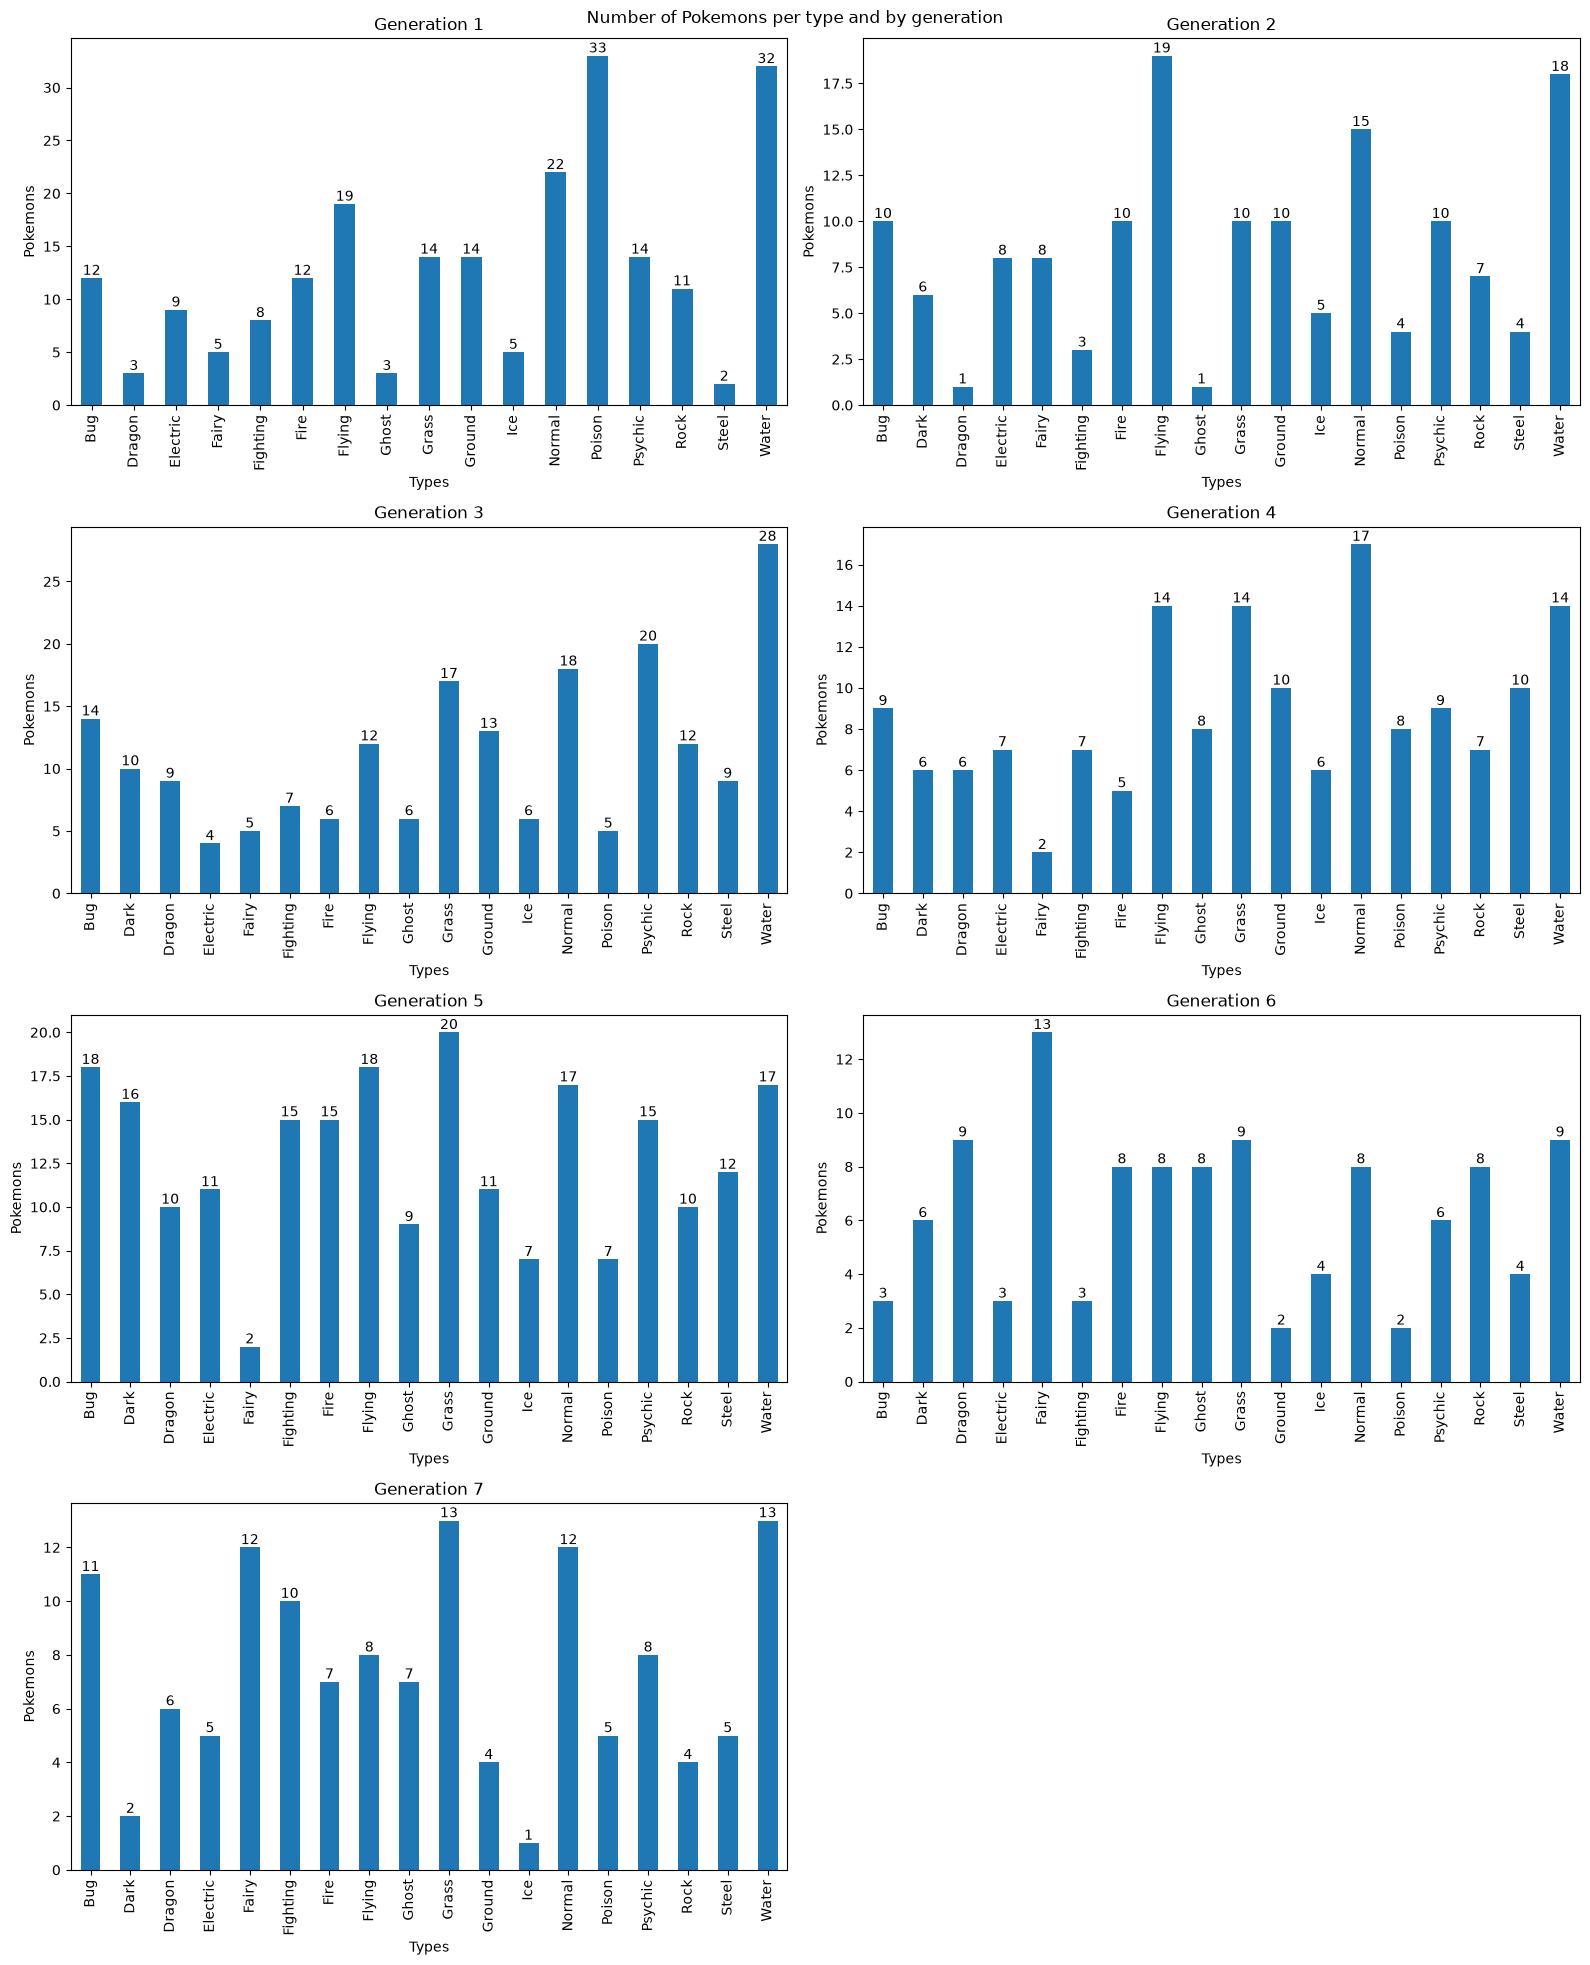

In [34]:
# Plot results
fig, axs = plt.subplots(4, 2, figsize=(16, 20))

for i, (ax, s) in enumerate(zip(axs.flat, s_of_types_count_by_generation)):
    s.plot(kind='bar', ax=ax, title=f'Generation {i+1}')
    ax.bar_label(ax.containers[0], fmt='%.0f')
    ax.set_xlabel('Types')
    ax.set_ylabel('Pokemons')

axs[3, 1].remove()  # hide the 8th (unused) subplot

fig.suptitle('Number of Pokemons per type and by generation')
plt.tight_layout()
plt.show()   